# system simulation

## service simulation
### nwk astract

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

EARTH_RADIUS = 6378.137  # km

#* per sate arrivals
N_max = 40 #* max task number within the constellation
a_max = 10e6 # 10M max task size
task_workload = 1e3 # 1k cyc/bit
link_bw = 10e9 # 10Gbps per link
fs = 10e9 # sat CPU freq
delta_t = 0.5 # slot length
max_time_span = 1e6 # slot num

#* constellation parameter setting
num_orbits = 10
num_sats_per_orbit = 10
altitude = 550.0
radius = altitude + EARTH_RADIUS
inclination = 53.0
phasediff = 0


## constellation setup

In [19]:
from const_simu import constellation

service_delta_const = constellation.ServiceDeltaConstellation(
    num_orbits=num_orbits, 
    num_sats_per_orbit=num_sats_per_orbit,
    radius=radius,
    inclination=inclination,
    phasediff=phasediff,
    fs=fs)

service_delta_const.update_constellation(delta_t)

## adding sats & orbits into the earth

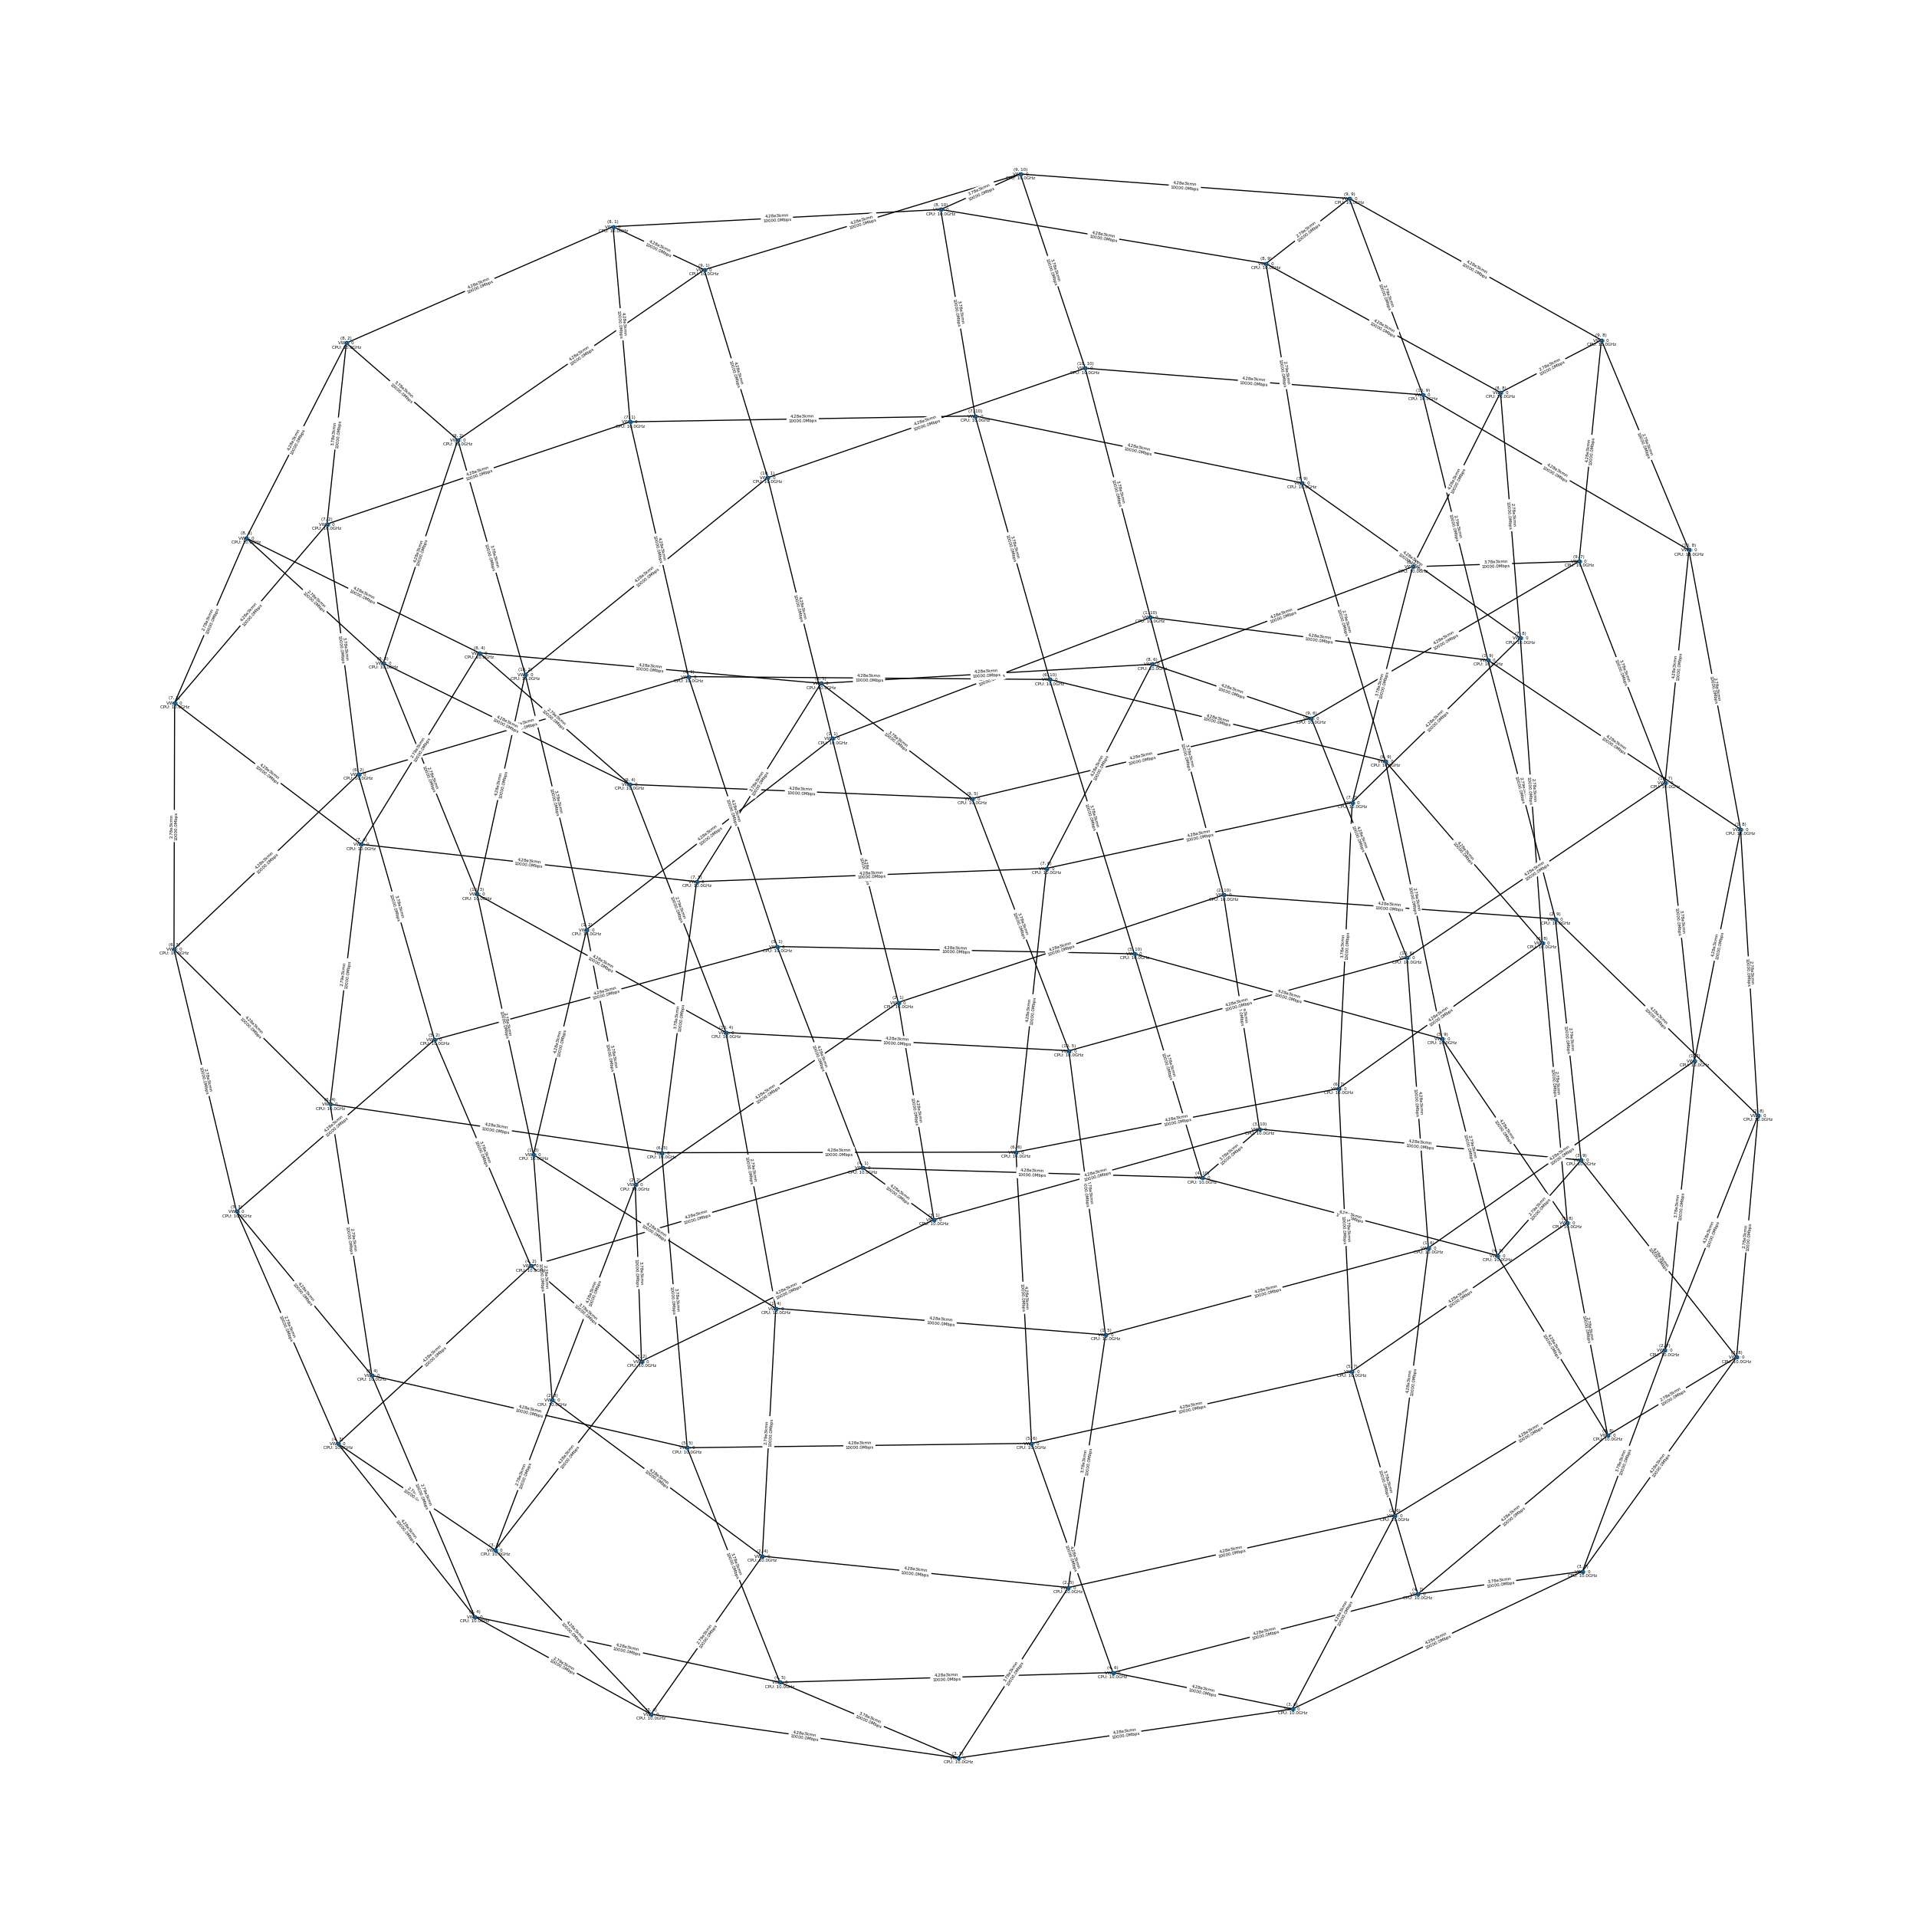

Widget(value='<iframe src="http://localhost:65482/index.html?ui=P_0x1a30c970350_1&reconnect=auto" class="pyvis…

In [20]:
from const_simu import network

service_delta_nwk = network.ServiceSatNetDelta(service_delta_const, N_max, a_max, task_workload, link_bw, delta_t, max_time_span)
service_delta_nwk.nwk_state_figure()
service_delta_nwk.show_earth_figure()